# Manual data download
Download the following files from the links below: 
- VDJ TCR - Filtered contig annotations (CSV), experiment name will end with "filtered_contig_annotations.csv"
- Gene Expression - Feature / cell matrix HDF5 (per-sample), experiment name will end with "filtered_feature_bc_matrix.h5"

https://www.10xgenomics.com/datasets/10k-human-a0201-pbmcs-with-cmv-flu-and-sars-cov2-spike-in-beam-t-2-standard

https://www.10xgenomics.com/datasets/5k-human-a0201-b0702-pbmcs-beam-t-2-standard

https://www.10xgenomics.com/datasets/10k-human-a2402-pbmcs-with-ebv-and-cmv-spike-in-beam-t-2-standard

https://www.10xgenomics.com/datasets/2k-mouse-h2kb-ot-1-splenocytes-beam-t-2-standard

Put the files into `../../data/BEAM-T/` which is the `BASE_PATH`

In [1]:
import os

# Change cwd to the notebook's directory for VS Code 
try:
    notebook_path = globals()['__vsc_ipynb_file__']
    notebook_dir = os.path.dirname(notebook_path)
    os.chdir(notebook_dir)
    print(f"Changed directory to: {notebook_dir}")
except:
    print("Could not find notebook path. Running from:", os.getcwd())

Changed directory to: /lustre/groups/imm01/workspace/yang/DextraDemixer/experiments/synthetic_benchmark


In [2]:
import os
import warnings

import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import muon as mu
import scirpy as ir
import scanpy as sc
import numpyro.distributions as npd
import statsmodels.api as sm
import statsmodels.formula.api as smf

from scipy import stats
from scipy.stats import truncnorm

warnings.catch_warnings()
warnings.simplefilter("ignore")

/opt/conda/envs/dextrademixer/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/opt/conda/envs/dextrademixer/lib/python3.13/site-packages/muon/_core/preproc.py:31: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  if Version(scanpy.__version__) < Version("1.10"):


In [3]:
BASE_PATH = '../../data/BEAM-T'
QUANTILE = 0.999
EXPERIMENTS = ['10k_BEAM-T_Human_A0201_CMV_Flu_Covid_spikein', '5k_BEAM-T_Human_A0201_B0702_PBMC', '10k_BEAM-T_Human_A2402_EBV_CMV_spikein', '2k_BEAM-T_Mouse_H2Kb_OT-1']

In [4]:
dataset_mapper = {'10k_BEAM-T_Human_A0201_CMV_Flu_Covid_spikein': '10k Human A0201', 
                  '5k_BEAM-T_Human_A0201_B0702_PBMC': '5k Human A0201 B0702', 
                  '10k_BEAM-T_Human_A2402_EBV_CMV_spikein': '10k Human A2402', 
                  '2k_BEAM-T_Mouse_H2Kb_OT-1': '2k Mouse H2Kb'}

In [5]:
# Figure settings
sns.reset_defaults()

global_settings = {
'font.size': 12, 'axes.titlesize': 'large', 'axes.labelsize': 'medium', 'xtick.labelsize': 'medium', 'ytick.labelsize': 'medium', 'legend.fontsize': 'medium', 'figure.titlesize': 'large',
    'figure.figsize': (3, 2.5), 'figure.dpi': 100, 'savefig.dpi': 300, 'savefig.bbox': 'tight', 'savefig.transparent': True,
}
plt.rcParams.update(global_settings)
os.makedirs('figures', exist_ok=True)
palette = {'signal': "#003eda", 'noise': "#00C3FF", 'negative control': "#9e9e9e", 'fit': "#FF0000",}

plt.rcParams.update({ 'axes.spines.top': False, 'axes.spines.right': False, })

## Load and preprocess data

In [6]:
# Create preprocessed mudata

for experiment in EXPERIMENTS: 
    if not os.path.exists(f'{BASE_PATH}/{experiment}_preprocessed.h5mu'):
        adata_tcr = ir.io.read_10x_vdj(f'{BASE_PATH}/{experiment}_5pv2_{experiment}_5pv2_vdj_t_filtered_contig_annotations.csv')
        adata = sc.read_10x_h5(f'{BASE_PATH}/{experiment}_5pv2_{experiment}_5pv2_count_sample_filtered_feature_bc_matrix.h5', gex_only=False)
        adata.var_names_make_unique()
        mdata = mu.MuData({"gex": adata, "airr": adata_tcr})
        ir.pp.index_chains(mdata)
        ir.tl.chain_qc(mdata)

        # keep T cells only, reduce gex to contain antigen barcodes only
        mdata = mdata[mdata.obs["airr:receptor_type"] == "TCR"]
        mdata = mdata[:, mdata.var["gex:feature_types"] == "Antigen Capture"]
    
        # minimal pMHC QC filtering
        sc.pp.filter_cells(mdata["gex"], min_genes=1)
        sc.pp.filter_genes(mdata["gex"], min_cells=10)
    
        mdata.update()
    
        mu.pp.filter_obs(mdata, "airr:chain_pairing", lambda x: ~np.isin(x, ["orphan VDJ", "orphan VJ"]))
        mu.pp.intersect_obs(mdata)
    
        ir.pp.ir_dist(mdata)  # Adds clone_id
        ir.tl.define_clonotypes(mdata, receptor_arms="all", dual_ir="primary_only")
    
        mdata.write(f'{BASE_PATH}/{experiment}_preprocessed.h5mu', compression='gzip')

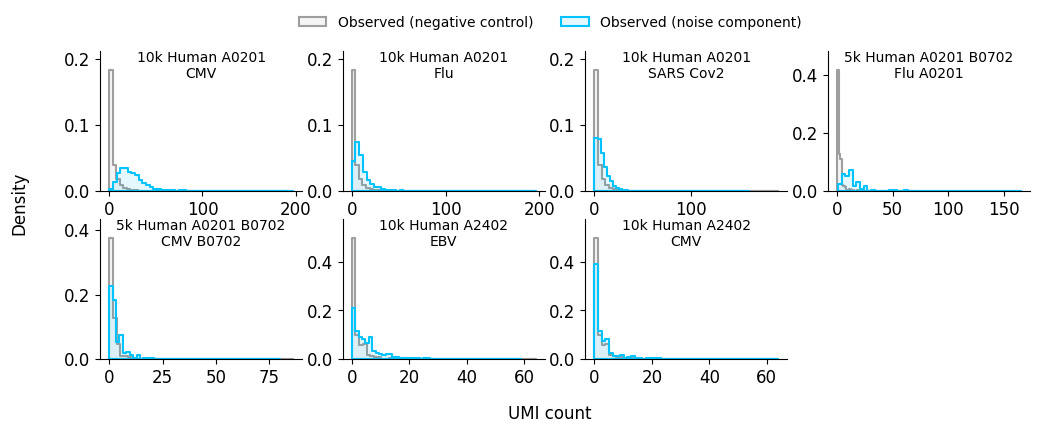

In [7]:
# SuppFig2a - Negative control and noise component overlap

params = []
nrows = 2
ncols = 4
fig = plt.figure(figsize=(3 * ncols, 2 * nrows))
i = 1

for experiment in EXPERIMENTS:
    mdata = mu.read(f'{BASE_PATH}/{experiment}_preprocessed.h5mu')
    genes = mdata.var['gex:gene_ids'].unique()

    for gene in genes:
        if 'negative' in gene:
            continue
        # Get negative control key
        if experiment == '5k_BEAM-T_Human_A0201_B0702_PBMC':  # Has two negative controls
            mhc = gene.split('_')[-1]
            neg_ctrl_key = [gene for gene in mdata.var['gex:gene_ids'].unique() if 'negative' in gene and mhc in gene][0]  # Get the negative control for the same MHC
        else:
            neg_ctrl_key = [gene for gene in mdata.var['gex:gene_ids'].unique() if 'negative' in gene][0]
        
        # Fit NB on negative control with outlier filtering based on quantile threshold
        x_neg = mdata['gex'][:, neg_ctrl_key].X.toarray().reshape(-1, )
        thr = np.quantile(x_neg, QUANTILE) if experiment != '2k_BEAM-T_Mouse_H2Kb_OT-1' else np.quantile(x_neg, 0.99 )  # 2k only 1339 samples
        x_neg_in_threshold = x_neg[x_neg <= thr]
        x = mdata['gex'][:, gene].X.toarray().reshape(-1, )

        if (x[x>thr].shape[0] < 20 or x[x<=thr].shape[0] < 20) and not 'negative' in gene:
            continue
        x_in_threshold = x[x <= thr]
        nbfit = smf.negativebinomial("nbdata ~ 1", data=pd.DataFrame({"nbdata": x_in_threshold})).fit(disp=False)
        mean = np.exp(nbfit.params.iloc[0])
        concentration = 1 / nbfit.params.iloc[1]

        # Fitted distribution for visualization
        x_range = np.arange(x_in_threshold.min(), x_in_threshold.max())
        prob = np.exp(npd.NegativeBinomial2(mean, concentration).log_prob(x_range))
        prob = prob / prob.sum()

        plt.subplot(nrows, ncols, i)
        ax = sns.histplot(x_neg_in_threshold, discrete=False, stat="density", bins=50, element='step', alpha=0.1, linewidth=1.5,
                          label='Observed (negative control)', color=palette['negative control'])
        ax = sns.histplot(x_in_threshold, discrete=False, stat="density", bins=50, element='step', alpha=0.1, linewidth=1.5,
                          label='Observed (noise component)', color=palette['noise'])
        
        plt.title(f'{dataset_mapper[experiment]}\n{gene.replace("negative_control", "neg. control").replace("_", " ")}', y=0.75, fontsize='small')
        plt.ylim(0, ax.get_ylim()[1]*1.1)
        plt.xlabel('')
        plt.ylabel('')
        sns.despine()
        if i == 1:
            ax = plt.gca()
            handles, labels = ax.get_legend_handles_labels()
        i += 1

fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.), ncol=2, frameon=False, fontsize='small')
fig.supxlabel('UMI count', fontsize='medium', y=-0.05)
fig.supylabel('Density', fontsize='medium', x=0.05)
os.makedirs('../../figures/SuppFig2', exist_ok=True)
plt.savefig('../../figures/SuppFig2/SuppFig2a_noise_negative_control_comparison.pdf')
plt.show()


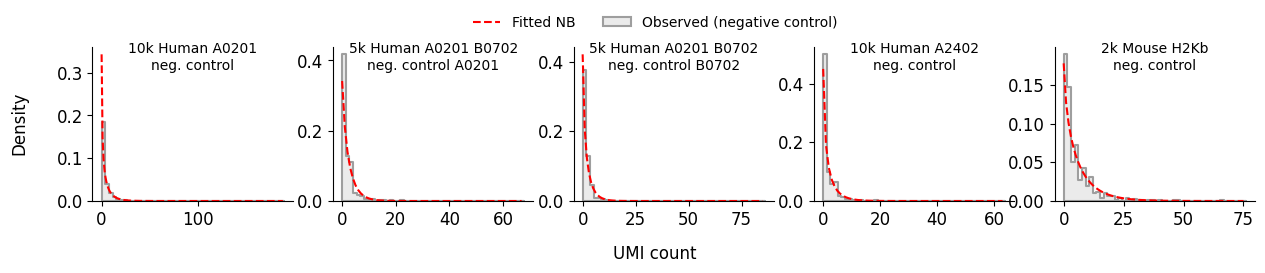

In [8]:
# SuppFig2b - Fitted distribution of negative control

params = []
nrows = 1
ncols = 5
fig = plt.figure(figsize=(3 * ncols, 2 * nrows))
i = 1
for experiment in EXPERIMENTS:
    mdata = mu.read(f'{BASE_PATH}/{experiment}_preprocessed.h5mu')
    genes = mdata.var['gex:gene_ids'].unique()
    for gene in [g for g in genes if 'negative' in g]:
        # Get negative control key
        if experiment == '5k_BEAM-T_Human_A0201_B0702_PBMC':  # Has two negative controls
            mhc = gene.split('_')[-1]
            neg_ctrl_key = [gene for gene in mdata.var['gex:gene_ids'].unique() if 'negative' in gene and mhc in gene][0]  # Get the negative control for the same MHC
        else:
            neg_ctrl_key = [gene for gene in mdata.var['gex:gene_ids'].unique() if 'negative' in gene][0]
        
        # Fit NB on negative control with outlier filtering based on quantile threshold
        x_neg = mdata['gex'][:, neg_ctrl_key].X.toarray().reshape(-1, )
        thr = np.quantile(x_neg, QUANTILE) if experiment != '2k_BEAM-T_Mouse_H2Kb_OT-1' else np.quantile(x_neg, 0.99 )  # 2k only 1339 samples
        x_in_threshold = x_neg[x_neg <= thr]
        nbfit = smf.negativebinomial("nbdata ~ 1", data=pd.DataFrame({"nbdata": x_in_threshold})).fit(disp=False)
        mean = np.exp(nbfit.params.iloc[0])
        concentration = 1 / nbfit.params.iloc[1]

        # Fitted distribution for visualization
        x_range = np.arange(x_in_threshold.min(), x_in_threshold.max())
        prob = np.exp(npd.NegativeBinomial2(mean, concentration).log_prob(x_range))
        prob = prob / prob.sum()

        plt.subplot(1, 5, i)
        plt.plot(x_range, prob, color=palette['fit'], ls='--', label='Fitted NB')
        ax = sns.histplot(x_in_threshold, discrete=False, stat="density", bins=50, label='Observed (negative control)', color=palette['negative control'], element='step', alpha=0.2, linewidth=1.5)
        plt.title(f'{dataset_mapper[experiment]}\n{gene.replace("negative_control", "neg. control").replace("_", " ")}', y=0.8, fontsize='small')
        plt.xlabel('')
        plt.ylabel('')
        sns.despine()
        if i == 1:
            ax = plt.gca()
            handles, labels = ax.get_legend_handles_labels()
        i += 1

fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.1), ncol=2, frameon=False, fontsize='small')
fig.supxlabel('UMI count', fontsize='medium', y=-0.2)
fig.supylabel('Density', fontsize='medium', x=0.07)
os.makedirs('../../figures/SuppFig2', exist_ok=True)
plt.savefig('../../figures/SuppFig2/SuppFig2b_negative_control_fit.pdf')
plt.show()


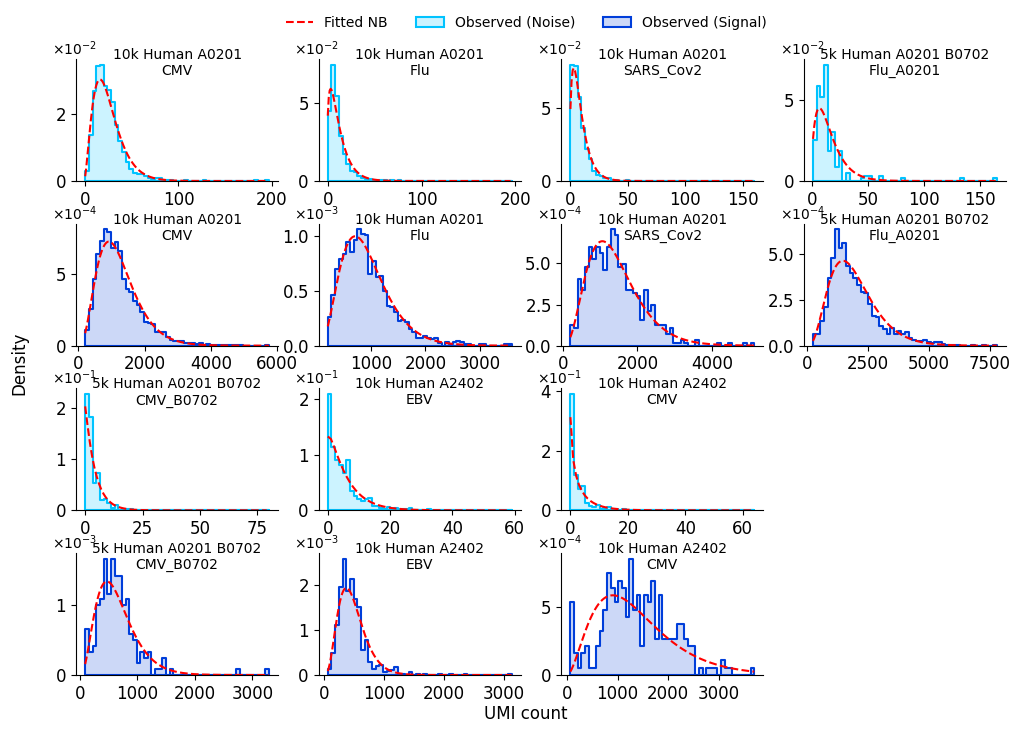

In [9]:
# SuppFig2c - Fitted distributions of pMHC signal and noise components
nrows = 4
ncols = 4

fig = plt.figure(figsize=(3 * ncols, 2. * nrows))
gene_plot_idx = 0 

# Initialize lists to track unique legend items
handles, labels = [], []
params = []

for experiment in EXPERIMENTS:
    mdata = mu.read(f'{BASE_PATH}/{experiment}_preprocessed.h5mu')
    genes = mdata.var['gex:gene_ids'].unique()

    for gene in genes:
        if 'negative' in gene:
            continue
            
        if experiment == '5k_BEAM-T_Human_A0201_B0702_PBMC': 
            mhc = gene.split('_')[-1]
            neg_ctrl_key = [g for g in mdata.var['gex:gene_ids'].unique() if 'negative' in g and mhc in g][0] 
        else:
            neg_ctrl_key = [g for g in mdata.var['gex:gene_ids'].unique() if 'negative' in g][0]
        
        x_neg = mdata['gex'][:, neg_ctrl_key].X.toarray().reshape(-1, )
        thr = np.quantile(x_neg, QUANTILE) if experiment != '2k_BEAM-T_Mouse_H2Kb_OT-1' else np.quantile(x_neg, 0.99 )  # 2k only 1339 samples
        x_neg_filtered = x_neg[x_neg <= thr]
        nbfit_neg = smf.negativebinomial("nbdata ~ 1", data=pd.DataFrame({"nbdata": x_neg_filtered})).fit(disp=False)
        mean_neg = np.exp(nbfit_neg.params.iloc[0])
        concentration_neg = 1 / nbfit_neg.params.iloc[1]

        x = mdata['gex'][:, gene].X.toarray().reshape(-1, )
        
        valid_noise = not ((x[x<=thr].shape[0] < 20) and not 'negative' in gene)
        valid_signal = not ((x[x>thr].shape[0] < 20) and not 'negative' in gene)
        if not valid_noise or not valid_signal:
            continue

        row_base = (gene_plot_idx // ncols) * 2
        col = gene_plot_idx % ncols

        for direction in ['-', '+']:
            x_in_threshold = x[x > thr] if direction == '+' else x[x <= thr]
            nbfit = smf.negativebinomial("nbdata ~ 1", data=pd.DataFrame({"nbdata": x_in_threshold})).fit(disp=False)
            mean = np.exp(nbfit.params.iloc[0])
            concentration = 1 / nbfit.params.iloc[1]
            var_nb = mean + mean ** 2 / concentration
            
            x_range = np.arange(x_in_threshold.min(), x_in_threshold.max())
            prob = np.exp(npd.NegativeBinomial2(mean, concentration).log_prob(x_range))
            prob = prob / prob.sum()

            row_offset = 0 if direction == '-' else 1
            plot_index = (row_base + row_offset) * ncols + col + 1
            
            ax = fig.add_subplot(nrows, ncols, plot_index)
            color_idx = 3 if direction == '-' else 1
            
            obs_label = 'Observed (Noise)' if direction == '-' else 'Observed (Signal)'
            
            ax.plot(x_range, prob, color=palette['fit'], ls='--', label='Fitted NB')
            sns.histplot(x_in_threshold, discrete=False, stat="density", bins=50, label=obs_label, color=palette['noise'] if direction == '-' else palette['signal'], ax=ax, alpha=0.2, element='step', linewidth=1.5)
                                    
            ax.set_title(f'{dataset_mapper[experiment]}\n{gene}', y=0.8, fontsize='small')
            ax.set_xlabel('')
            ax.set_ylabel('')
            ax.ticklabel_format(axis='y', style='sci', scilimits=(0,0), useMathText=True)

            offset_text = ax.yaxis.get_offset_text()
            offset_text.set_fontsize('small')
            offset_text.set_position((-0.12, 0.5))
            sns.despine(ax=ax)

            # Extract unique legend handles
            for h, l in zip(*ax.get_legend_handles_labels()):
                if l not in labels:
                    handles.append(h)
                    labels.append(l)
            
        gene_plot_idx += 1 

if handles:
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.95), ncol=3, frameon=False, fontsize=10)

fig.supxlabel('UMI count', fontsize='medium', y=0.05)
fig.supylabel('Density', fontsize='medium', x=0.07)
fig.subplots_adjust(hspace=0.35)
plt.savefig('../../figures/SuppFig2/SuppFig2c_signal_noise_fit.pdf', bbox_inches='tight')
plt.show()

In [10]:
# Determine fitted distributions parameters
params = []
for experiment in EXPERIMENTS:
    mdata = mu.read(f'{BASE_PATH}/{experiment}_preprocessed.h5mu')
    genes = mdata.var['gex:gene_ids'].unique()

    for gene in genes:
        # Get negative control key
        if experiment == '5k_BEAM-T_Human_A0201_B0702_PBMC':  # Has two negative controls
            mhc = gene.split('_')[-1]
            neg_ctrl_key = [gene for gene in mdata.var['gex:gene_ids'].unique() if 'negative' in gene and mhc in gene][0]  # Get the negative control for the same MHC
        else:
            neg_ctrl_key = [gene for gene in mdata.var['gex:gene_ids'].unique() if 'negative' in gene][0]
        
        # Fit NB on negative control with outlier filtering based on quantile threshold
        x_neg = mdata['gex'][:, neg_ctrl_key].X.toarray().reshape(-1, )
        thr = np.quantile(x_neg, QUANTILE) if experiment != '2k_BEAM-T_Mouse_H2Kb_OT-1' else np.quantile(x_neg, 0.99 )  # 2k only 1339 samples
        x_neg_filtered = x_neg[x_neg <= thr]
        nbfit_neg = smf.negativebinomial("nbdata ~ 1", data=pd.DataFrame({"nbdata": x_neg_filtered})).fit(disp=False)
        mean_neg = np.exp(nbfit_neg.params.iloc[0])
        concentration_neg = 1 / nbfit_neg.params.iloc[1]
        var_nb_neg = mean_neg + mean_neg ** 2 / concentration_neg
        
        param = {'experiment': experiment, 'gene': gene, 'threshold': thr,
				 f'mean_neg': mean_neg, f'concentration_neg': concentration_neg,
				 f'var_nb_neg': var_nb_neg, 'overdisp_nb_neg': var_nb_neg / mean_neg,
                }

        x = mdata['gex'][:, gene].X.toarray().reshape(-1, )
        for direction in ['-', '+']:
            x_in_threshold = x[x > thr] if direction == '+' else x[x <= thr]
            nbfit = smf.negativebinomial("nbdata ~ 1", data=pd.DataFrame({"nbdata": x_in_threshold})).fit(disp=False)
            mean = np.exp(nbfit.params.iloc[0])
            concentration = 1 / nbfit.params.iloc[1]
            var_nb = mean + mean ** 2 / concentration
            
            param.update({f'mean{direction}': mean, f'concentration{direction}': concentration, 
                          f'var_nb{direction}': var_nb, 
                          f'overdisp_nb{direction}': var_nb / mean, 
                          f'N{direction}': x_in_threshold.shape[0],})

        
        params.append(param)

params = pd.DataFrame(params)
for key in [f'mean', f'concentration', f'var_nb', f'overdisp_nb', f'N']:
    params[f'{key}_ratio'] = params[f'{key}+'] / params[f'{key}-']
params['binder_ratio'] = params['N+'] / (params['N-'] + params['N+'])
params['noise_to_neg_mean_ratio'] = params['mean-'] / params['mean_neg']
params['neg_inc'] = params['mean-'] / params['mean_neg']
params['noise_to_neg_overdisp_ratio'] = params['overdisp_nb-'] / params['overdisp_nb_neg']
params

,experiment,gene,threshold,mean_neg,concentration_neg,var_nb_neg,overdisp_nb_neg,mean-,concentration-,var_nb-,...,N+,mean_ratio,concentration_ratio,var_nb_ratio,overdisp_nb_ratio,N_ratio,binder_ratio,noise_to_neg_mean_ratio,neg_inc,noise_to_neg_overdisp_ratio
0,10k_BEAM-T_Human_A0201_CMV_Flu_Covid_spikein,CMV,197.938477,3.867945,0.489523,34.430371,8.901464,25.003214,2.897500,240.761868,...,3773,49.212545,1.354419,1607.540828,32.665265,2.020889,0.668972,6.464212,6.464212,1.081759
1,10k_BEAM-T_Human_A0201_CMV_Flu_Covid_spikein,EBV_BMLF-1_GLCT,197.938477,3.867945,0.489523,34.430371,8.901464,1.454062,0.231539,10.585553,...,2,172.963772,107.313660,264.241278,1.527726,0.000355,0.000355,0.375926,0.375926,0.817842
2,10k_BEAM-T_Human_A0201_CMV_Flu_Covid_spikein,Flu,197.938477,3.867945,0.489523,34.430371,8.901464,11.730760,1.432491,107.794731,...,1391,78.636249,2.942561,1881.321785,23.924358,0.327371,0.246631,3.032815,3.032815,1.032309
3,10k_BEAM-T_Human_A0201_CMV_Flu_Covid_spikein,EBV_BRLF1_YVLD,197.938477,3.867945,0.489523,34.430371,8.901464,2.596270,0.386810,20.022444,...,10,312.294178,7.326876,11625.436849,37.225916,0.001776,0.001773,0.671227,0.671227,0.866375
4,10k_BEAM-T_Human_A0201_CMV_Flu_Covid_spikein,SARS_Cov2,197.938477,3.867945,0.489523,34.430371,8.901464,8.543229,1.653138,52.693679,...,574,165.537081,2.422136,9505.974155,57.425044,0.113304,0.101773,2.208726,2.208726,0.692907
5,10k_BEAM-T_Human_A0201_CMV_Flu_Covid_spikein,negative_control,197.938477,3.867945,0.489523,34.430371,8.901464,3.867945,0.489523,34.430371,...,6,208.637941,4.966156,7804.024882,37.404630,0.001065,0.001064,1.000000,1.000000,1.000000
6,5k_BEAM-T_Human_A0201_B0702_PBMC,Flu_A0201,173.383301,2.114713,0.873756,7.232860,3.420256,15.505495,1.876203,143.647475,...,2227,125.773976,2.192459,6449.982473,51.282329,12.236264,0.924450,7.332197,7.332197,2.708656
7,5k_BEAM-T_Human_A0201_B0702_PBMC,CMV_B0702,87.184082,1.782627,0.662888,6.576434,3.689182,3.732883,1.053218,16.963204,...,189,174.126735,3.431894,6928.957342,39.792610,0.085135,0.078456,2.094035,2.094035,1.231781
8,5k_BEAM-T_Human_A0201_B0702_PBMC,negative_control_A0201,173.383301,2.114713,0.873756,7.232860,3.420256,2.114713,0.873756,7.232860,...,3,299.646619,1.778455,35813.138102,119.517911,0.001247,0.001245,1.000000,1.000000,1.000000
9,5k_BEAM-T_Human_A0201_B0702_PBMC,negative_control_B0702,87.184082,1.782627,0.662888,6.576434,3.689182,1.782627,0.662888,6.576434,...,3,337.142924,1.605272,51705.636364,153.364145,0.001247,0.001245,1.000000,1.000000,1.000000


## Negative control distribution

In [11]:
neg_ctrl_params = params[params['gene'].str.contains('negative')].copy()
neg_ctrl_params[['mean-', 'concentration-', 'var_nb-', 'overdisp_nb-', 'N-']]

,mean-,concentration-,var_nb-,overdisp_nb-,N-
5,3.867945,0.489523,34.430371,8.901464,5634
8,2.114713,0.873756,7.232860,3.420256,2406
9,1.782627,0.662888,6.576434,3.689182,2406
12,1.801178,0.549719,7.702813,4.276543,2887
14,5.961509,0.812680,49.692846,8.335615,1325


Truncated log-normal params:  -1.0539178917389453 1.8375518345106894 1.0181158793900795 0.4175162931163312


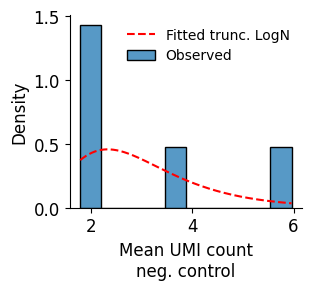

In [12]:
# SuppFig 2d - Fit negative control mean distribution using weighted MoM lognormal
ns, means = neg_ctrl_params['N-'].to_numpy(float), neg_ctrl_params['mean-'].to_numpy(float)
w = ns / ns.sum()
m = np.sum(w * means)
v = np.sum(w * (means - m)**2)
sigma2 = np.log(1 + v / m**2)
sigma  = np.sqrt(sigma2)
mu_ln  = np.log(m) - 0.5 * sigma2
low, high = means.min(), means.max()
a, b = (np.log(low) - mu_ln) / sigma, (np.log(high) - mu_ln) / sigma
samples = np.exp(truncnorm(a, b, loc=mu_ln, scale=sigma).rvs(1000, random_state=0))
print(f'Truncated log-normal params: ', a, b, mu_ln, sigma)

# Plot
plt.figure(figsize=(3, 2.5))
x_range = np.linspace(low, high, 500)
dist = stats.lognorm(s=sigma, scale=np.exp(mu_ln))
pdf_base = dist.pdf(x_range)
Z = dist.cdf(high) - dist.cdf(low)
pdf_truncated = pdf_base / Z

sns.histplot(means, stat='density', bins=10, label='Observed', )
plt.plot(x_range, pdf_truncated, color=palette['fit'], ls='--', label='Fitted trunc. LogN')
sns.despine()
plt.legend(frameon=False, fontsize='small')
plt.xlabel('Mean UMI count\nneg. control')
plt.ylabel('Density')
plt.savefig('../../figures/SuppFig2/SuppFig2d_negative_control_mean_fit.pdf')
plt.show()

## Non-binder distribution

trunc log-normal params for noise:  -1.4325807532116341 1.9485510504360744 2.0461540382126118 0.6019089551720753
lowest sampled value 3.267036725146729


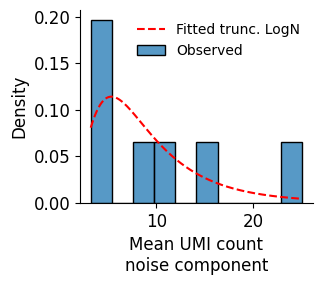

In [13]:
# SuppFig 2e - Fit negative control mean distribution using weighted MoM lognormal
noise = params[~params['gene'].str.contains('negative', na=False)]
noise = noise[(noise[['N-', 'N+']] > 20).all(1)]
ns, means = noise['N-'].to_numpy(float), noise['mean-'].to_numpy(float)
w = ns / ns.sum()
m = np.sum(w * means)
v = np.sum(w * (means - m)**2)
sigma2 = np.log(1 + v / m**2)
sigma  = np.sqrt(sigma2)
mu_ln  = np.log(m) - 0.5 * sigma2
low, high = means.min(), means.max()
a, b = (np.log(low) - mu_ln) / sigma, (np.log(high) - mu_ln) / sigma
samples = np.exp(truncnorm(a, b, loc=mu_ln, scale=sigma).rvs(100000, random_state=0))
print('trunc log-normal params for noise: ', a, b, mu_ln, sigma)
print('lowest sampled value', samples.min())

# Plot
fig = plt.figure(figsize=(3, 2.5))
x_range = np.linspace(low, high, 500)
dist = stats.lognorm(s=sigma, scale=np.exp(mu_ln))
pdf_base = dist.pdf(x_range)
Z = dist.cdf(high) - dist.cdf(low)
pdf_truncated = pdf_base / Z

sns.histplot(means, stat='density', bins=10, label='Observed', )
plt.plot(x_range, pdf_truncated, color='red', ls='--', label='Fitted trunc. LogN')
sns.despine()
plt.legend(frameon=False, fontsize='small', ncols=1)
plt.xlabel('Mean UMI count\nnoise component')
plt.ylabel('Density')
plt.savefig('../../figures/SuppFig2/SuppFig2e_noise_mean_fit.pdf')
plt.show()


## Log-linear relationship between mean and variance

In [14]:
epitope_params = params[~params['gene'].str.contains('negative')].copy()
epitope_params = epitope_params[(epitope_params['N-'] > 20) & (epitope_params['N+'] > 20)]
neg_ctrl_params = params[params['gene'].str.contains('negative')].copy()

signal_params = epitope_params[['mean+', 'var_nb+']].copy()
signal_params['set'] = 'signal'
signal_params.columns = signal_params.columns.str.replace('+', '')

noise_params = epitope_params[['mean-', 'var_nb-']].copy()
noise_params['set'] = 'noise'
noise_params.columns = noise_params.columns.str.replace('-', '')

control_params = neg_ctrl_params[['mean-', 'var_nb-']].copy()
control_params['set'] = 'control'
control_params.columns = control_params.columns.str.replace('-', '')

all_params = pd.concat([signal_params, noise_params, control_params])
all_params['log_var'] = np.log(all_params['var_nb'])
all_params['log_mean'] = np.log(all_params['mean'])

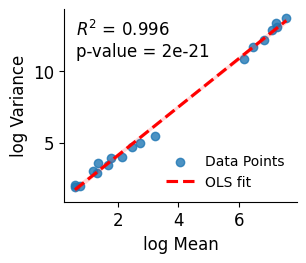

                            OLS Regression Results                            
Dep. Variable:                log_var   R-squared:                       0.996
Model:                            OLS   Adj. R-squared:                  0.995
Method:                 Least Squares   F-statistic:                     3774.
Date:                Thu, 18 Jun 2026   Prob (F-statistic):           2.09e-21
Time:                        21:02:01   Log-Likelihood:                -4.2241
No. Observations:                  19   AIC:                             12.45
Df Residuals:                      17   BIC:                             14.34
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.7042      0.124      5.697      0.0

In [15]:
# SuppFig 2f - Mean-variance log-linear relationship in negative control, noise and signal components
model = sm.OLS(all_params["log_var"], sm.add_constant(all_params["log_mean"])).fit()

# visualize
x_grid = np.linspace(all_params["log_mean"].min(), all_params["log_mean"].max(), 200)
y_pred = model.params[0] + model.params[1] * x_grid

all_params["log_mean"] = np.log(all_params["mean"])
all_params["log_var"] = np.log(all_params["var_nb"])

sns.regplot(all_params, x='log_mean', y='log_var', line_kws={'color': palette['fit'], 'ls': '--'})
plt.legend(['Data Points', 'OLS fit', ], frameon=False, fontsize='small')
plt.xlabel(f'log Mean')
plt.ylabel(f'log Variance')
plt.text(0.05, 0.95, f'$R^2$ = {model.rsquared:.3f}\np-value = {model.f_pvalue:.0e}', transform=plt.gca().transAxes, fontsize='medium', verticalalignment='top')
plt.savefig('../../figures/SuppFig2/SuppFig2f_mean_variance_relationship.pdf')
plt.show()

print(model.summary())


0.31049623532404286


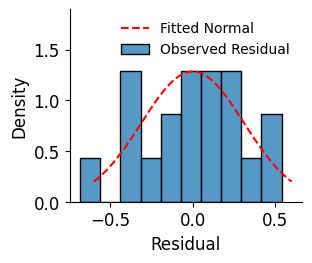

In [16]:
# SuppFig 2g - Residual distribution of mean-variance fit
resid_std = model.resid.std(ddof=1)
print(resid_std)
plt.figure(figsize=(3, 2.5))
sns.histplot(model.resid, bins=10, stat='density', label='Observed Residual')
sns.lineplot(x=np.linspace(-0.6, 0.6, 100), y=stats.norm(0, resid_std).pdf(np.linspace(-0.6, 0.6, 100)), c='r', ls='--', label='Fitted Normal')
sns.despine()
plt.ylim(0, plt.ylim()[1] * 1.4)
plt.legend(frameon=False, fontsize='small')
plt.xlabel('Residual')
plt.savefig('../../figures/SuppFig2/SuppFig2g_mean_variance_residuals.pdf')
plt.show()

## Clone size

[np.float64(0.2550120234076684), np.float64(1151.0), np.float64(1.0)]


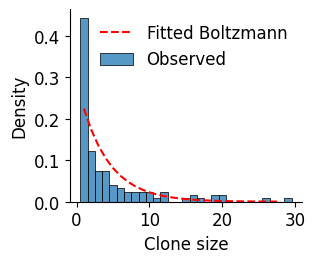

In [17]:
# SuppFig 2h - Clone size distribution fit to Boltzmann
def remove_outliers(sr, iq_range=0.8):
    #  https://stackoverflow.com/a/39424972
    pcnt = (1 - iq_range) / 2
    qlow, median, qhigh = np.quantile(sr[~np.isnan(sr)], [pcnt, 0.50, 1 - pcnt])
    iqr = qhigh - qlow
    return sr[np.abs((sr - median)) <= iqr]


fp = f'{BASE_PATH}/10k_BEAM-T_Human_A0201_CMV_Flu_Covid_spikein_preprocessed.h5mu'
mdata = mu.read(fp)

# fit clonotype size distribution
clone_size = mdata.mod['airr'].obs.groupby("clone_id", dropna=False).size()
rv = stats.boltzmann
bounds = [(0, 10000), (1, np.max(clone_size)), (1, 1)]
clone_size = remove_outliers(clone_size, 0.8)
res = stats.fit(rv, clone_size, bounds)
print(list(res.params))

sns.histplot(clone_size, discrete=True, bins=100, stat='density', label='Observed')
x = np.arange(clone_size.min(), clone_size.max())
pdf = rv.pmf(x, *res.params)
sns.lineplot(x=x, y=pdf, color='r', ls='--', label='Fitted Boltzmann')
plt.legend(frameon=False)
plt.xlabel('Clone size')
plt.savefig(f'../../figures/SuppFig2/SuppFig2h_clone_size_fit.pdf')
plt.show()


## Relationship between noise and control (for negative control model)

In [18]:
# Fitted distribution parameters are used for DextraDemixer negative control extension
epitope_params = params[~params['gene'].str.contains('negative')]

In [21]:
# Mean ratio between noise and negative control
# Weighted MoM lognormal params
ns, means = epitope_params['N-'].to_numpy(float), epitope_params['noise_to_neg_mean_ratio'].to_numpy(float)
w = ns / ns.sum()
w = 1 / ns.shape[0]
m = np.sum(w * means)
v = np.sum(w * (means - m)**2)
sigma2 = np.log(1 + v / m**2)
sigma  = np.sqrt(sigma2)
mu_ln  = np.log(m) - 0.5 * sigma2
print(f'log-normal params: ', mu_ln, sigma)

log-normal params:  0.9692917285815053 0.629397707490648


In [20]:
# Overdispersion ratio between noise and negative control
# Weighted MoM lognormal params
ns, means = epitope_params['N-'].to_numpy(float), epitope_params['noise_to_neg_overdisp_ratio'].to_numpy(float)
w = ns / ns.sum()
w = 1 / ns.shape[0]
m = np.sum(w * means)
v = np.sum(w * (means - m)**2)
sigma2 = np.log(1 + v / m**2)
sigma  = np.sqrt(sigma2)
mu_ln  = np.log(m) - 0.5 * sigma2
print(f'log-normal params for s: ', mu_ln, sigma)

log-normal params for s:  0.19724303327974957 0.4397080632187905
